In [131]:
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold



In [132]:
# Load the movies_scaled_dummies.csv file from the data folder
movies_scaled = pd.read_csv('../data/movies_scaled_dummies.csv')
movies_scaled.head()

,Budget,Gross,Release Date,Runtime,Rating,Rating Count,Net Profit,ROI,Genre_Frequency,MPAA Rating_G,...,Genre_Family,Genre_Fantasy,Genre_History,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
0,-1.284438,296000000.0,10,-1.100607,-1.146270,-0.831512,288500000.0,38.466667,0.051282,0,...,0,0,0,0,0,1,0,0,0,0
1,-1.284438,145793296.0,12,-0.832114,0.549913,-0.776143,138293296.0,18.439106,0.185404,0,...,0,0,0,0,0,0,0,0,0,0
2,-1.191530,71079915.0,7,-0.787365,0.323756,-0.775063,58079915.0,4.467686,0.031558,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.174637,161001698.0,12,1.226329,0.323756,-0.775063,147001698.0,10.500121,0.015779,0,...,0,0,0,0,0,0,0,0,1,0
4,-1.157745,84431625.0,4,-0.474124,0.662992,-0.742398,69431625.0,4.628775,0.110454,0,...,0,0,0,0,0,0,0,0,0,0


In [133]:
# sine/cosine encoding is better for cyclic variables like release month (months of a year are cyclic) vs one hot encoding
movies_scaled['release_month_sin'] = np.sin(2*np.pi*movies_scaled['Release Date']/12)
movies_scaled['release_month_cos'] = np.cos(2*np.pi*movies_scaled['Release Date']/12)

In [134]:
# removing these columns, no longer needed
movies_scaled = movies_scaled.drop(columns=['Release Date','Genre_Frequency'])

In [135]:
# checking corrilations to gross
movies_scaled.corr()

,Budget,Gross,Runtime,Rating,Rating Count,Net Profit,ROI,MPAA Rating_G,MPAA Rating_PG,MPAA Rating_PG-13,...,Genre_History,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western,release_month_sin,release_month_cos
Budget,1.000000,0.668835,0.243004,0.012263,0.287585,0.501018,-0.396112,0.064558,-0.011023,0.255308,...,-0.042360,-0.082137,0.036924,-0.167211,0.107607,-0.020149,0.013008,-0.024919,0.085965,-0.186794
Gross,0.668835,1.000000,0.272471,0.229864,0.504918,0.978474,0.088852,0.068877,-0.002777,0.218153,...,-0.035844,-0.087906,-0.004652,-0.041677,0.066243,-0.032015,-0.000315,-0.031524,0.082069,-0.124477
Runtime,0.243004,0.272471,1.000000,0.369038,0.393776,0.249737,-0.038652,-0.233406,-0.318845,0.174512,...,0.160717,-0.009066,0.105718,-0.043297,0.080764,0.043918,0.221810,0.094088,-0.019809,0.095538
Rating,0.012263,0.229864,0.369038,1.000000,0.662830,0.264190,0.179752,0.030877,-0.107903,-0.062611,...,0.071942,-0.036074,-0.015073,-0.157505,0.082883,0.013136,0.071634,0.057310,-0.088165,0.135549
Rating Count,0.287585,0.504918,0.393776,0.662830,1.000000,0.507963,0.127620,-0.005582,-0.176128,0.153793,...,0.032137,-0.052266,-0.021221,-0.116368,0.128322,0.038232,0.030512,0.036764,0.002552,-0.028866
Net Profit,0.501018,0.978474,0.249737,0.264190,0.507963,1.000000,0.213397,0.062262,-0.000172,0.183088,...,-0.029968,-0.079534,-0.015666,-0.002100,0.047245,-0.031677,-0.003977,-0.029781,0.071676,-0.093055
ROI,-0.396112,0.088852,-0.038652,0.179752,0.127620,0.213397,1.000000,-0.019837,0.001869,-0.100581,...,0.031381,0.044029,-0.055553,0.186706,-0.081705,-0.008505,-0.003684,0.043477,-0.032811,0.101095
MPAA Rating_G,0.064558,0.068877,-0.233406,0.030877,-0.005582,0.062262,-0.019837,1.000000,-0.134652,-0.208602,...,-0.020860,-0.029619,-0.033183,-0.011968,-0.059707,-0.061733,-0.029619,-0.023346,-0.051404,-0.005528
MPAA Rating_PG,-0.011023,-0.002777,-0.318845,-0.107903,-0.176128,-0.000172,0.001869,-0.134652,1.000000,-0.516398,...,-0.051640,-0.073324,0.016429,-0.026380,-0.014304,-0.134298,-0.073324,-0.057793,0.070982,0.061822
MPAA Rating_PG-13,0.255308,0.218153,0.174512,-0.062611,0.153793,0.183088,-0.100581,-0.208602,-0.516398,1.000000,...,-0.035000,-0.049697,-0.012726,0.034737,0.086790,0.053807,-0.081645,0.031336,0.006146,-0.101033


<Axes: >

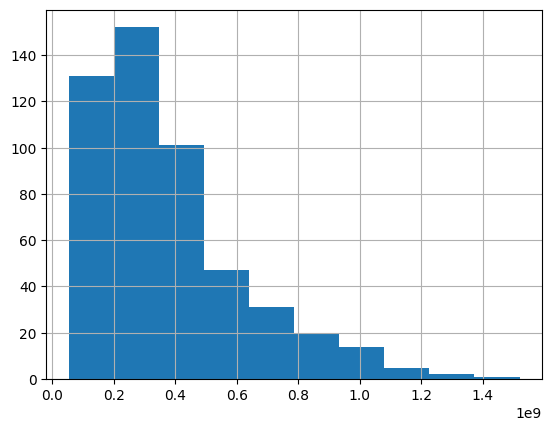

In [136]:
movies_scaled["Gross"].hist()

Becasue the gross is scewed we are going to take to log to get a more normal distruption and reduce impact of outliers

In [137]:
y_log = np.log1p(movies_scaled["Gross"])

# we can drop Gross and Net Profit becasue they are highly correlated with each other
# ROI will also be dropped because it is calculated from Gross and Net Profit
#  and we will use y_log as the target variable
X = movies_scaled.drop(columns=['Gross', 'Net Profit', 'ROI'])

In [138]:
# Split the data into 70% training and 30% testing sets
# We can't predict Gross log and not inculde ROI because it is calculated from the Gross

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.3, random_state=42)

In [139]:
# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross, ROI, and Net Profit revenue on the test set
y_pred = rf.predict(X_test)

In [140]:
# Show training R^2 score
train_r2 = r2_score(y_train, rf.predict(X_train))

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Perform K-Fold cross validation on SVR model

kf = KFold(n_splits=20, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y_log, cv=kf, scoring='r2')

print(f"k fold Mean R^2 Score: {cv_scores.mean():.4f}")

print(f"Random Forest Training R^2 Score: {train_r2:.4f}")
print(f"Random Forest Mean Squared Error: {mse:.4f}")
print(f"Random Forest Mean Absolute Error: {mae:.4f}")
print(f"Random Forest Testing R^2 Score: {r2:.4f}")


k fold Mean R^2 Score: 0.6038
Random Forest Training R^2 Score: 0.9462
Random Forest Mean Squared Error: 0.1768
Random Forest Mean Absolute Error: 0.3217
Random Forest Testing R^2 Score: 0.5729


Now we can see how Xboost compairs

In [141]:

# Create and fit an XGBoost Regressor model on the training set
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = xgb.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Perform K-Fold cross validation on SVR model

kf = KFold(n_splits=20, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgb, X, y_log, cv=kf, scoring='r2')

print(f"k fold Mean R^2 Score: {cv_scores.mean():.4f}")

print(f"XGBoost Training R^2 Score: {train_r2:.4f}")
print(f"XGBoost Mean Squared Error: {mse:.4f}")
print(f"XGBoost Mean Absolute Error: {mae:.4f}")
print(f"XGBoost Testing R^2 : {r2:.4f}")

k fold Mean R^2 Score: 0.5425
XGBoost Training R^2 Score: 0.9462
XGBoost Mean Squared Error: 0.2004
XGBoost Mean Absolute Error: 0.3370
XGBoost Testing R^2 : 0.5160


LinearRegression

In [142]:
# Create and fit a Linear Regression model on the training set
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict the target variables on the test set
y_pred = lr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, lr.predict(X_train))

# Perform K-Fold cross validation on SVR model

kf = KFold(n_splits=20, shuffle=True, random_state=42)

cv_scores = cross_val_score(lr, X, y_log, cv=kf, scoring='r2')

print(f"k fold Mean R^2 Score: {cv_scores.mean():.4f}")

print(f"Training Linear Regression R^2 Score: {train_r2:.4f}")
print(f"Linear Regression Mean Squared Error: {mse:.4f}")
print(f"Linear Regression Mean Absolute Error: {mae:.4f}")
print(f"Linear Regression Testing R^2 Score: {r2:.4f}")

k fold Mean R^2 Score: 0.5333
Training Linear Regression R^2 Score: 0.6082
Linear Regression Mean Squared Error: 0.1825
Linear Regression Mean Absolute Error: 0.3442
Linear Regression Testing R^2 Score: 0.5592


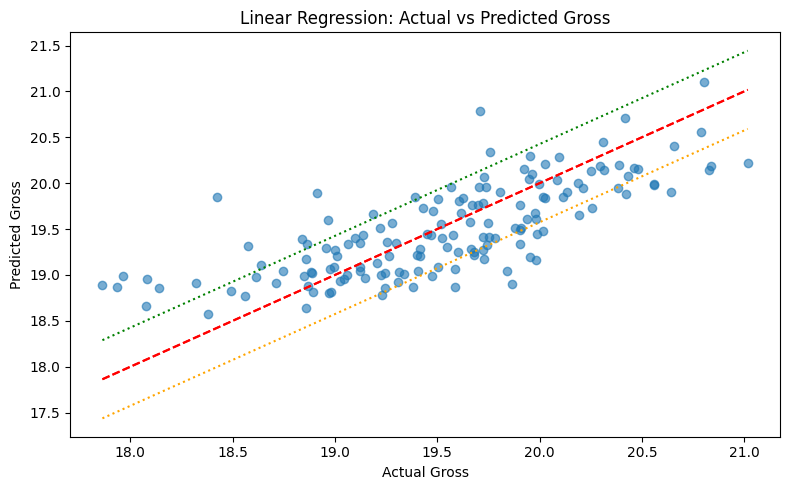

In [143]:
# Plot actual vs predicted values for the linear regression model
residuals = y_test - y_pred
std_error = np.std(residuals)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("Linear Regression: Actual vs Predicted Gross")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_error, y_test.max() + std_error], color='green', linestyle=':', linewidth=1.5, label=f'+1 STD ({std_error:.2f})')
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_error, y_test.max() - std_error], color='orange', linestyle=':', linewidth=1.5, label=f'-1 STD ({std_error:.2f})')
plt.tight_layout()
plt.show()

Linear regression shows a corrilation in this graph, but it isn't completely linear.

In [144]:

# Create and fit a Support Vector Regressor model on the training set
svr = SVR()
svr.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = svr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, svr.predict(X_train))

kf = KFold(n_splits=20, shuffle=True, random_state=42)
cv_scores = cross_val_score(svr, X, y_log, cv=kf, scoring='r2')

print(f"k fold Mean R^2 Score: {cv_scores.mean():.4f}")

print(f"Training SVR R^2 Score: {train_r2:.4f}")
print(f"SVR Mean Squared Error: {mse:.4f}")
print(f"SVR Mean Absolute Error: {mae:.4f}")
print(f"SVR R^2 Testing Score: {r2:.4f}")

k fold Mean R^2 Score: 0.5837
Training SVR R^2 Score: 0.8136
SVR Mean Squared Error: 0.1630
SVR Mean Absolute Error: 0.3159
SVR R^2 Testing Score: 0.6063


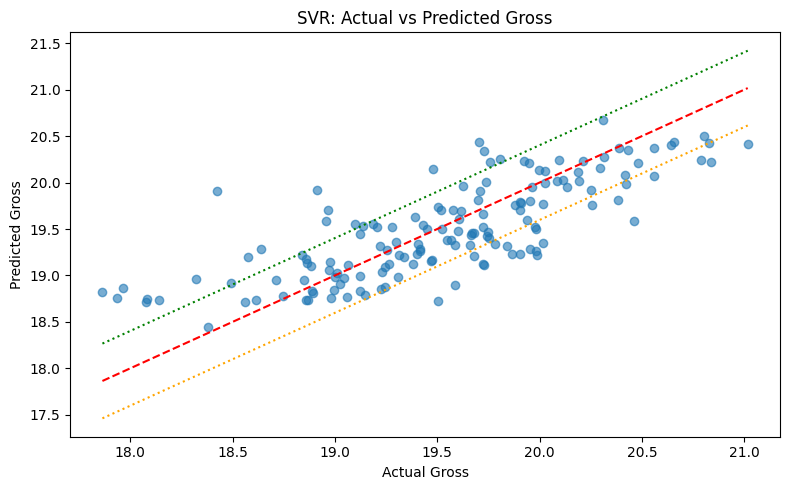

In [145]:
residuals = y_test - y_pred
std_error = np.std(residuals)
# Plot actual vs predicted values for the linear regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("SVR: Actual vs Predicted Gross")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.plot([y_test.min(), y_test.max()], [y_test.min() + std_error, y_test.max() + std_error], color='green', linestyle=':', linewidth=1.5, label=f'+1 STD ({std_error:.2f})')
plt.plot([y_test.min(), y_test.max()], [y_test.min() - std_error, y_test.max() - std_error], color='orange', linestyle=':', linewidth=1.5, label=f'-1 STD ({std_error:.2f})')
plt.tight_layout()
plt.show()

<h1>The following is a summary of the model testing R^2 values</h1>

Random Forest k fold Mean R^2 Score: 0.6038  
Random Forest Testing R^2 Score: 0.5729

XGB k fold Mean R^2 Score: 0.5425  
XGBoost Testing R^2 : 0.5160 

Linear k fold Mean R^2 Score: 0.5333  
Linear Regression Testing R^2 Score: 0.5592  

SVR k fold Mean R^2 Score: 0.5837  
SVR R^2 Testing Score: 0.6063


SVR preforms best based on R^2 testing score and k fold testing. Random Forest could also be chosen, they have very similar statistics. SVR has a slightly lower mean absolute error though 0.31 vs 0.32.  

We will select SVR for our model

Lets use the Support Vecotr Machine and do hyperperameter tuning

In [115]:
# Define parameter grid for SVR
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'degree': [2, 3, 4]  # Only used for 'poly' kernel
}

# Create SVR model
svr = SVR()

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=20,
    n_jobs=-1,
    verbose=2
)

# Run grid search
grid_search.fit(X_train, y_train)

# Output results
print("Best parameters found:", grid_search.best_params_)
print("Best CV score (MSE):", grid_search.best_score_)
print("Best CV score (MAE):", (-1*grid_search.best_score_)**.5)

# Evaluate on test data
best_svr = grid_search.best_estimator_
test_score = best_svr.score(X_test, y_test)
print("Test R² score:", test_score)

Fitting 20 folds for each of 180 candidates, totalling 3600 fits
Best parameters found: {'C': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV score (MSE): -0.17734935687449685
Best CV score (MAE): 0.42112867021196365
Test R² score: 0.6321057919268058


Using those hyper parameters it increased the R^2 to .63. That will be the final model that is saved.

In [70]:
# Prepare the full dataset for training
# This is the final model that will be saved
X_full = movies_scaled.drop('Gross', axis=1)
y_full = y_log
svr = SVR(kernel = 'rbf' ,C = 1 , gamma = 'auto', degree = 2)

# Fit the final model
svr.fit(X_full, y_full)


SVR(C=1, degree=2, gamma='auto')

In [71]:
# Export the trained SVR model to a pickle file
joblib.dump(svr, '../data/movies_svr.pkl')

['../data/movies_svr.pkl']